
<a id='chap-tparbresdecision'></a>

# Assignment 1 - Decision Trees

The objective of this assignment is to demonstrate the implementation of decision trees for classification and regression problems. This document freely reproduces some examples shown in the excellent scikit-learn documentation.

Useful external references

- [NumPy documentation](https://docs.scipy.org/doc/numpy/user/index.html)  
- [SciPy documentation](https://docs.scipy.org/doc/scipy/reference/)  
- [MatPlotLib documentation](http://matplotlib.org/)  
- [scikit-learn](http://scikit-learn.org/stable/index.html)  
- [Python Programming languages](https://www.python.org)  

## Decision trees

Decision trees are nonparametric learning methods used for classification and regression problems. The goal is to create a model that predicts the values of the target variable, based on a set of sequences of decision rules inferred from the training data. The tree therefore approximates the target by a succession of if-then-else rules. This paradigm applies to both categorical and numerical data. The more complex the tree generated, the better the model “explains” the learning data but the higher the risk of over-fitting.

Decision trees have several advantages that make them interesting in contexts where it is useful to understand the sequence of decisions made by the model:

•	They are easy to understand and visualize.

•	They require little data preparation (normalization, etc.).

•	The cost of using trees is logarithmic.

•	They can use categorical and numerical data.

•	They can deal with multi-class problems.

•	White box model: the result is easy to conceptualize and visualize.

However, these models have two major disadvantages:

•	Over-fitting: sometimes the generated trees are too complex and generalize badly. Choosing good values for the maximum depth (max_depth) and minimum number of samples per leaf (min_samples_leaf) parameters avoids this problem.

•	It may happen that the generated trees are not balanced, which implies that the travel time is no longer logarithmic. It is therefore recommended to adjust the dataset before construction, to avoid that one class largely dominates the others in terms of the number of training examples


## Trees for classification

In scikit-learn, the class [sklearn.tree.DecisionTreeClassifier](http://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html) allows to perform a multi-class classification using a decision tree.

We start by importing the right modules and building the tree object:

In [ ]:
# To install the last version of sklearn
!pip install -U scikit-learn

In [ ]:
from sklearn import tree
clf = tree.DecisionTreeClassifier()

For the example, we can define a minimalist dataset (two points, each in a class):

In [ ]:
X = [[0, 0], [1, 1]]
y = [0, 1]

The tree is built using the `.fit(X, y)` method:

In [ ]:
clf = clf.fit(X, y)

Prediction on new samples is done in the usual way with `.predict(X)` :

In [ ]:
clf.predict([[2., 2.]])

array([1])

One can also predict the probability of each class for a sample:

In [ ]:
clf.predict_proba([[2., 2.]])

array([[0., 1.]])

## Classification of Iris data

`DecisionTreeClassifier` is able to handle multi-class classification problems (eg with labels 0, 1, … K-1). In this example we will work with the [Iris](https://archive.ics.uci.edu/ml/datasets/Iris) dataset, , easily accessible in `sklearn`. This dataset contains 150 instances of iris (a type of plant, each observation describes its morphology). The objective is to classify each instance into one of three categories: *Iris setosa*, *Iris virginica* or *Iris versicolor*.

One of the classes is linearly separable with respect to the other two, but the other two are not separable with respect to each other.


<dl style='margin: 20px 0;'>
<dt>The attributes of the dataset are:</dt>
<dd>
- sepal length,  
- sepal width,  
- petal length,  
- petal width,
- class: Iris Setosa, Iris Versicolor or Iris Virginica.


</dd>

</dl>

The Iris dataset being very common, scikit-learn offers a native function to load it into memory:

In [ ]:
from sklearn.datasets import load_iris
import numpy as np
import matplotlib.pyplot as plt

iris = load_iris()
X, y = iris.data, iris.target

## Question 1

Calculate the statistics (mean and standard deviation) of the four explanatory variables: sepal length, sepal width, petal length and petal width.

In [ ]:
# Load the Iris dataset
iris = load_iris()
X, y = iris.data, iris.target

# Calculate mean and standard deviation for each feature
means = np.mean(X, axis=0)
std_devs = np.std(X, axis=0)

# Print the results
feature_names = iris.feature_names
for i, feature in enumerate(feature_names):
    print(f"{feature}: Mean = {means[i]:.2f}, Standard Deviation = {std_devs[i]:.2f}")


sepal length (cm): Mean = 5.84, Standard Deviation = 0.83
sepal width (cm): Mean = 3.06, Standard Deviation = 0.43
petal length (cm): Mean = 3.76, Standard Deviation = 1.76
petal width (cm): Mean = 1.20, Standard Deviation = 0.76


## Question 2

How many examples of each class are there?

Before building the model, let's split the dataset into two: 70% for training, 30% for testing.

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state=0)

We can now build a decision tree on this data:

In [ ]:
from sklearn import tree
clf = tree.DecisionTreeClassifier()
clf.fit(X_train, y_train)

DecisionTreeClassifier()

Once the training is finished, we can visualize the tree, either with  `matplotlib` using the `plot_tree` method, or with the  `graphviz` tool (dot command). For example, with  `matplotlib`:

[Text(0.4, 0.9, 'x[3] <= 0.75\ngini = 0.664\nsamples = 105\nvalue = [34, 32, 39]'),
 Text(0.3, 0.7, 'gini = 0.0\nsamples = 34\nvalue = [34, 0, 0]'),
 Text(0.35, 0.8, 'True  '),
 Text(0.5, 0.7, 'x[2] <= 4.95\ngini = 0.495\nsamples = 71\nvalue = [0, 32, 39]'),
 Text(0.45, 0.8, '  False'),
 Text(0.2, 0.5, 'x[3] <= 1.65\ngini = 0.161\nsamples = 34\nvalue = [0, 31, 3]'),
 Text(0.1, 0.3, 'gini = 0.0\nsamples = 30\nvalue = [0, 30, 0]'),
 Text(0.3, 0.3, 'x[1] <= 3.1\ngini = 0.375\nsamples = 4\nvalue = [0, 1, 3]'),
 Text(0.2, 0.1, 'gini = 0.0\nsamples = 3\nvalue = [0, 0, 3]'),
 Text(0.4, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [0, 1, 0]'),
 Text(0.8, 0.5, 'x[2] <= 5.05\ngini = 0.053\nsamples = 37\nvalue = [0, 1, 36]'),
 Text(0.7, 0.3, 'x[1] <= 2.75\ngini = 0.375\nsamples = 4\nvalue = [0, 1, 3]'),
 Text(0.6, 0.1, 'gini = 0.0\nsamples = 3\nvalue = [0, 0, 3]'),
 Text(0.8, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [0, 1, 0]'),
 Text(0.9, 0.3, 'gini = 0.0\nsamples = 33\nvalue = [0, 0, 33]')]

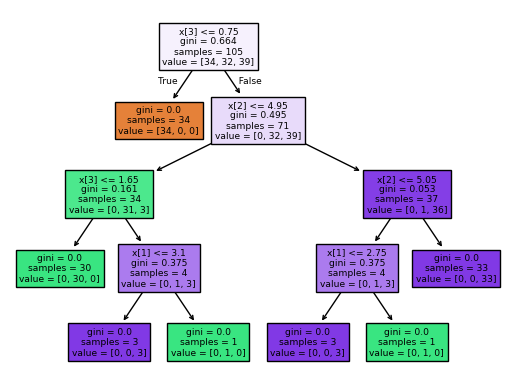

In [ ]:
tree.plot_tree(clf, filled=True)

Alternatively, it is possible to export by producing a `.dot` file which is the default format of `graphviz`:

In [ ]:
# Export the graph to the iris.dot file
with open("iris.dot", 'w') as f:
    f = tree.export_graphviz(clf, out_file=f, filled=True)

Then, on the command line, it is possible to convert this file into many formats, for example into PDF (shell command):

## Note

Currently, this command does not work on CNAM's JupyterHub because dot is not installed.

In [ ]:
%%bash
dot -Tpdf iris.dot -o iris.pdf

The generated image should look like this:

 <img src="https://scikit-learn.org/stable/_images/iris.png" style="width:100%;">


Once the model is built, it is possible to use it for prediction on new data:

In [ ]:
clf.predict(X_test)

array([2, 1, 0, 2, 0, 2, 0, 1, 1, 1, 2, 1, 1, 1, 1, 0, 1, 1, 0, 0, 2, 1,
       0, 0, 2, 0, 0, 1, 1, 0, 2, 1, 0, 2, 2, 1, 0, 2, 1, 1, 2, 0, 2, 0,
       0])

The test score can be calculated this way:

In [ ]:
clf.score(X_test, y_test)

0.9777777777777777

## Question 3:

Change the `max_depth` and `min_samples_leaf` parameter values. What do you notice?

max_depth = None, min_samples_leaf = 1
Training Score: 1.0000, Testing Score: 0.9778


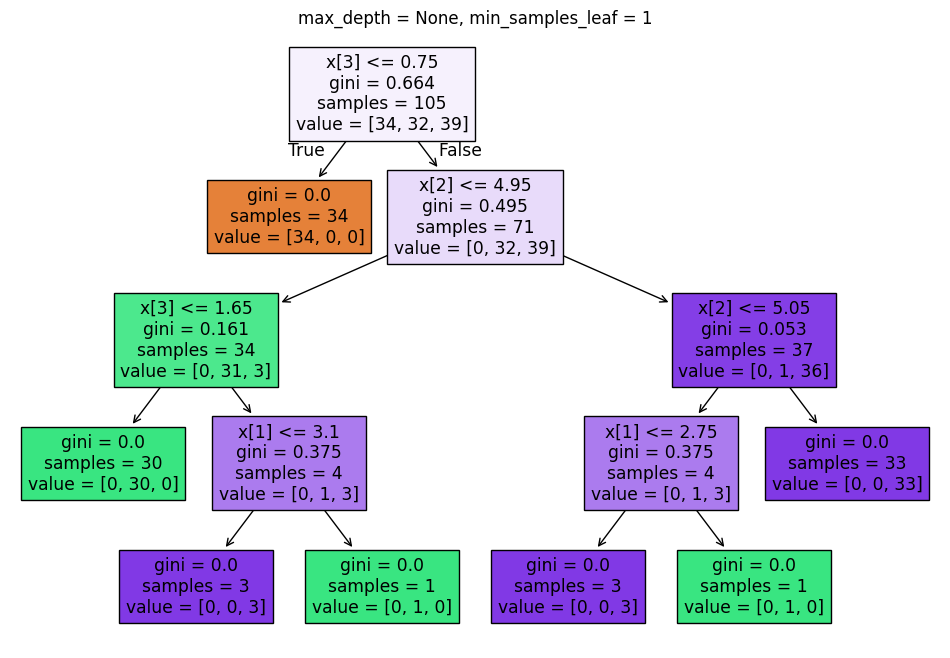

max_depth = 3, min_samples_leaf = 1
Training Score: 0.9810, Testing Score: 0.9778


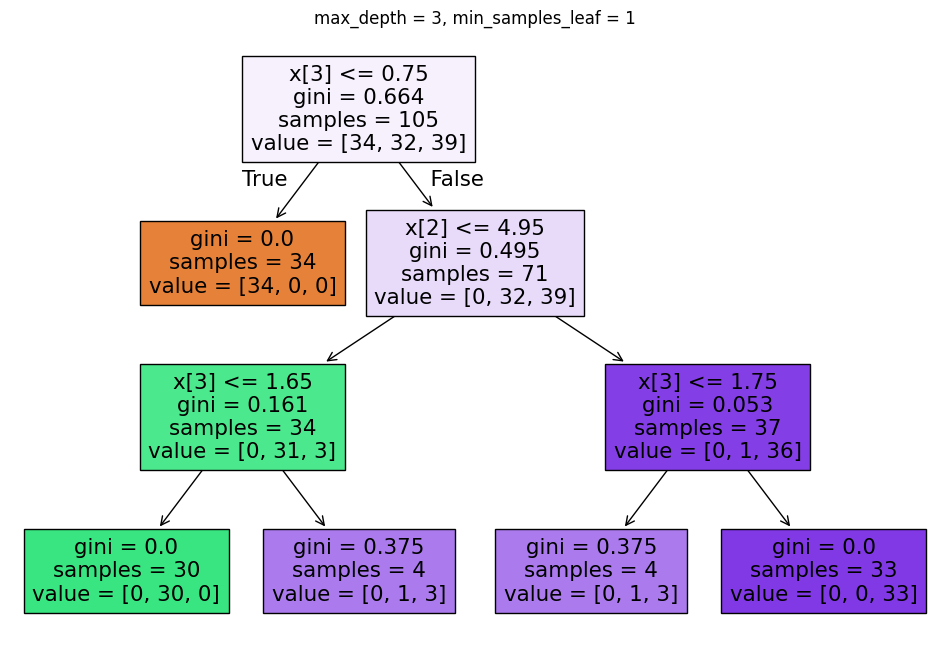

max_depth = 3, min_samples_leaf = 5
Training Score: 0.9619, Testing Score: 0.9111


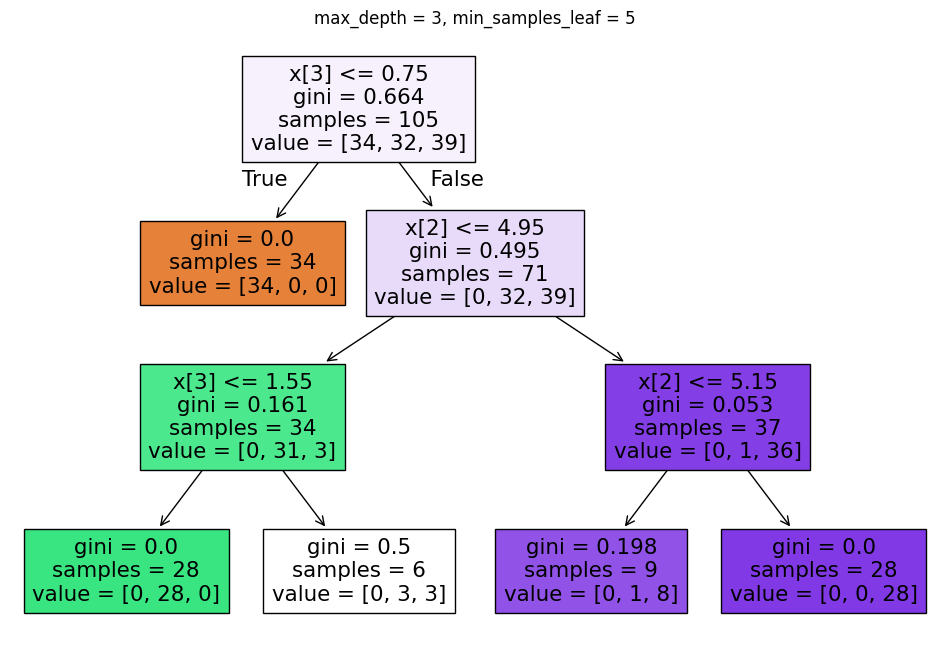

max_depth = 5, min_samples_leaf = 10
Training Score: 0.9619, Testing Score: 0.9111


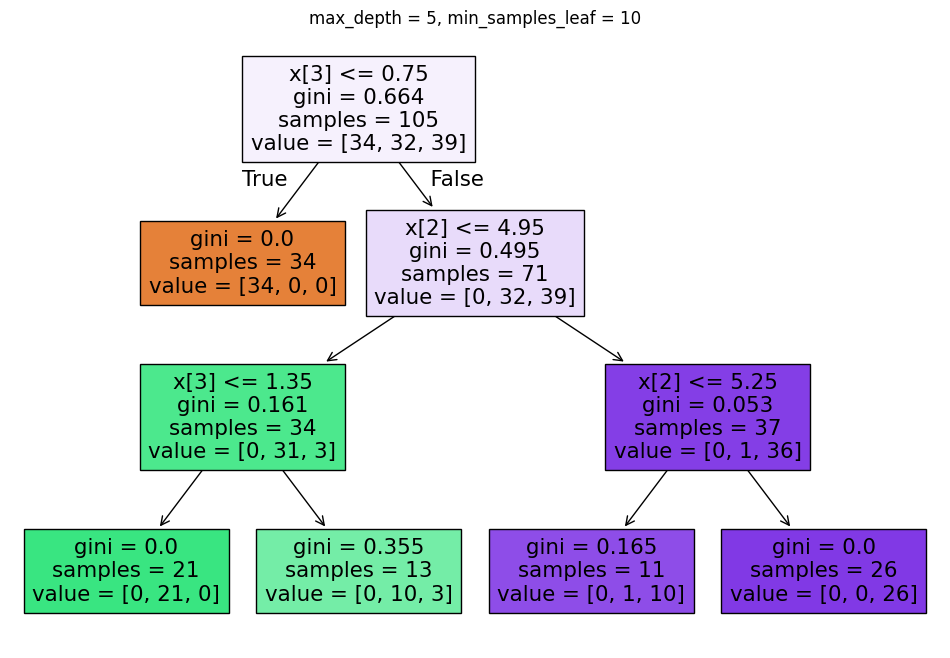

max_depth = 2, min_samples_leaf = 4
Training Score: 0.9619, Testing Score: 0.9111


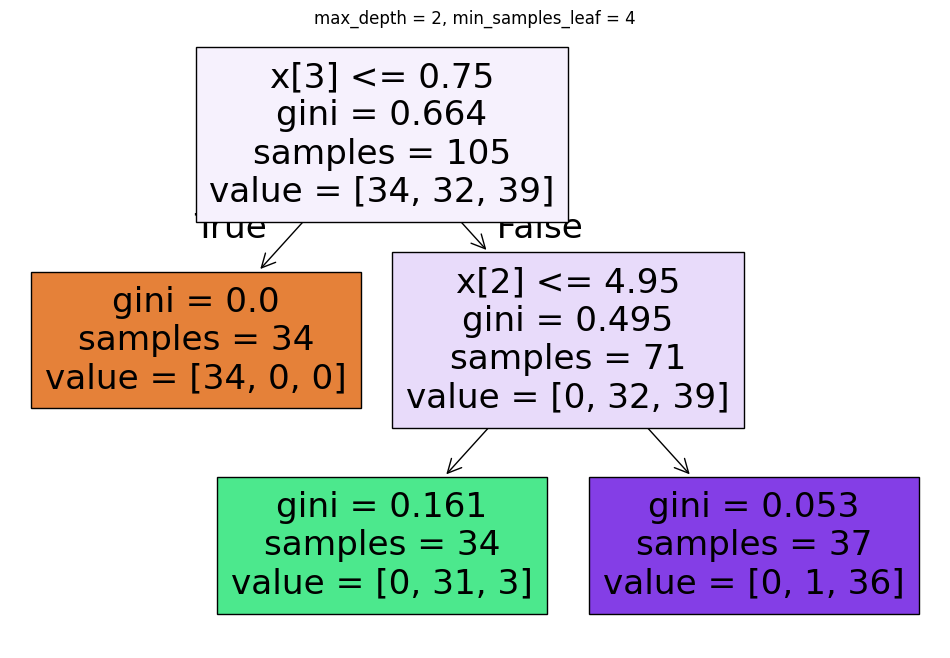

In [ ]:
# Function to train and evaluate a decision tree with different parameters
def evaluate_tree(max_depth, min_samples_leaf):
    clf = tree.DecisionTreeClassifier(max_depth=max_depth, min_samples_leaf=min_samples_leaf)
    clf.fit(X_train, y_train)
    train_score = clf.score(X_train, y_train)
    test_score = clf.score(X_test, y_test)
    print(f"max_depth = {max_depth}, min_samples_leaf = {min_samples_leaf}")
    print(f"Training Score: {train_score:.4f}, Testing Score: {test_score:.4f}")
    return clf
    # Test different configurations of max_depth and min_samples_leaf
configs = [
    (None, 1),   # Default depth, default min_samples_leaf
    (3, 1),      # Limited depth
    (3, 5),      # Limited depth and more samples per leaf
    (5, 10),     # Deeper tree but larger leaves
    (2, 4)       # Shallow tree with more samples per leaf
]

# Evaluate each configuration and visualize the tree
for max_depth, min_samples_leaf in configs:
    clf = evaluate_tree(max_depth, min_samples_leaf)
    plt.figure(figsize=(12, 8))
    tree.plot_tree(clf, filled=True)
    plt.title(f"max_depth = {max_depth}, min_samples_leaf = {min_samples_leaf}")
    plt.show()

## Question 4:

The problem here being particularly simple, redo a training/test division with 5% of the data in training and 95% test.
Calculate the rate of misclassified items on the test set.
Vary (or better, perform a grid search with `GridSearchCV`) the values of the `max_depth` and `min_samples_leaf` parameters to measure their impact on this score.

In [ ]:
from sklearn import tree
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score
import numpy as np
import matplotlib.pyplot as plt

# Load the Iris dataset
iris = load_iris()
X, y = iris.data, iris.target

# Split the data into 5% training and 95% testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.05, random_state=0)

# Define the parameter grid for max_depth and min_samples_leaf
param_grid = {
    'max_depth': [1, 2, 3, 4, 5, None],  # None means no limit
    'min_samples_leaf': [1, 2, 4, 5, 10, 20]
}

# Initialize a DecisionTreeClassifier
clf = tree.DecisionTreeClassifier()

# Perform a grid search with cross-validation
grid_search = GridSearchCV(clf, param_grid, cv=3, scoring='accuracy')
grid_search.fit(X_train, y_train)

# Get the best parameters from the grid search
best_params = grid_search.best_params_
best_clf = grid_search.best_estimator_

print(f"Best parameters: {best_params}")

# Predict on the test set with the best model
y_pred = best_clf.predict(X_test)

# Calculate the misclassification rate
misclassification_rate = 1 - accuracy_score(y_test, y_pred)
print(f"Misclassification Rate: {misclassification_rate:.4f}")

# Summary of the best model performance
print(f"Training Score: {best_clf.score(X_train, y_train):.4f}")
print(f"Testing Score: {best_clf.score(X_test, y_test):.4f}")


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_split.py:776: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(


Best parameters: {'max_depth': 2, 'min_samples_leaf': 1}
Misclassification Rate: 0.1119
Training Score: 1.0000
Testing Score: 0.8881


###   Display of the decision surface

For a pair of attributes, i.e., for two-dimensional observations, we can visualize the decision surface in 2 dimensions. First, we discretize the two-dimensional domain with a constant step and then we evaluate the model on each point of the grid.


In this example, we only keep the length and width of the petals.

<ipython-input-18-0f376a9ad563>:33: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X[idx, 0], X[idx, 1], c=color, label=iris.target_names[i], cmap=plt.cm.Paired)


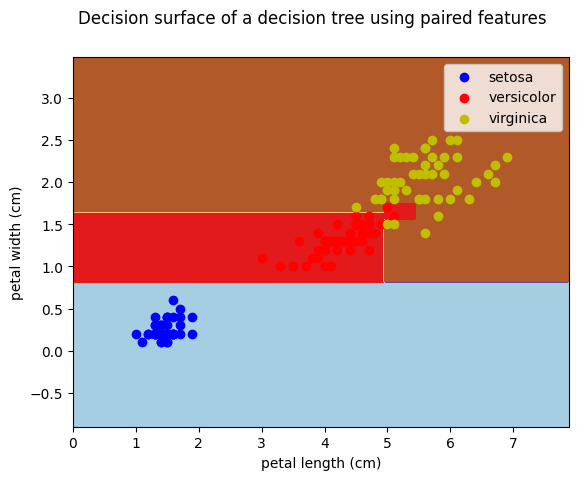

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Settings
n_classes = 3
plot_colors = "bry" # blue-red-yellow
plot_step = 0.02

# Choose the length and width attributes of the petals
pair = [2, 3]

# We only keep the two attributes
X = iris.data[:, pair]
y = iris.target

# Tree learning
clf = tree.DecisionTreeClassifier().fit(X, y)

# Display of the decision surface
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step), np.arange(y_min, y_max, plot_step))
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
cs = plt.contourf(xx, yy, Z, cmap=plt.cm.Paired)
plt.xlabel(iris.feature_names[pair[0]])
plt.ylabel(iris.feature_names[pair[1]])
plt.axis("tight")

# Display of learning points
for i, color in zip(range(n_classes), plot_colors):
    idx = np.where(y == i)
    plt.scatter(X[idx, 0], X[idx, 1], c=color, label=iris.target_names[i], cmap=plt.cm.Paired)
plt.axis("tight")
plt.suptitle("Decision surface of a decision tree using paired features")
plt.legend()
plt.show()

### Question 5:

Redo the display for the other pairs of attributes. On which pair is the separation between the classes the most marked?

 **Sepal Length vs. Sepal Width (indices 0 and 1):**

<ipython-input-19-7f1898c3d41e>:33: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X[idx, 0], X[idx, 1], c=color, label=iris.target_names[i], cmap=plt.cm.Paired)


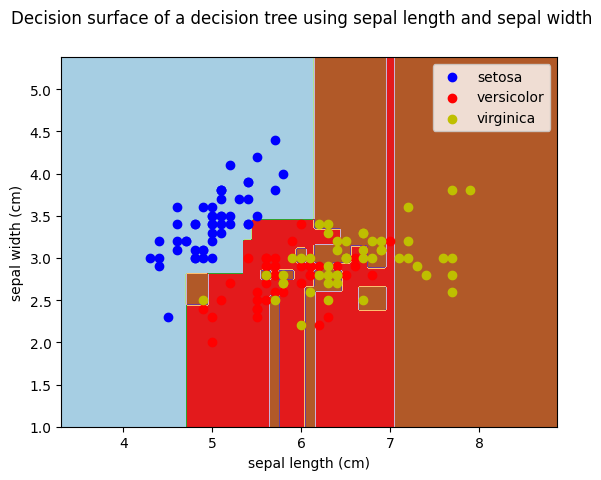

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Settings
n_classes = 3
plot_colors = "bry"  # blue-red-yellow
plot_step = 0.02

# Choose the sepal length and sepal width attributes
pair = [0, 1]

# We only keep the two attributes
X = iris.data[:, pair]
y = iris.target

# Tree learning
clf = tree.DecisionTreeClassifier().fit(X, y)

# Display of the decision surface
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step), np.arange(y_min, y_max, plot_step))
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
cs = plt.contourf(xx, yy, Z, cmap=plt.cm.Paired)
plt.xlabel(iris.feature_names[pair[0]])
plt.ylabel(iris.feature_names[pair[1]])
plt.axis("tight")

# Display of learning points
for i, color in zip(range(n_classes), plot_colors):
    idx = np.where(y == i)
    plt.scatter(X[idx, 0], X[idx, 1], c=color, label=iris.target_names[i], cmap=plt.cm.Paired)
plt.axis("tight")
plt.suptitle("Decision surface of a decision tree using sepal length and sepal width")
plt.legend()
plt.show()


**Sepal Length vs. Petal Length (indices 0 and 2)**

<ipython-input-20-47992ae4cb1f>:33: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X[idx, 0], X[idx, 1], c=color, label=iris.target_names[i], cmap=plt.cm.Paired)


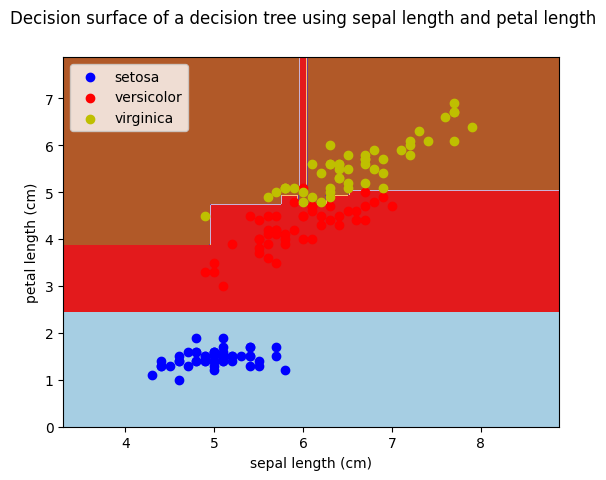

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Settings
n_classes = 3
plot_colors = "bry"  # blue-red-yellow
plot_step = 0.02

# Choose the sepal length and petal length attributes
pair = [0, 2]

# We only keep the two attributes
X = iris.data[:, pair]
y = iris.target

# Tree learning
clf = tree.DecisionTreeClassifier().fit(X, y)

# Display of the decision surface
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step), np.arange(y_min, y_max, plot_step))
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
cs = plt.contourf(xx, yy, Z, cmap=plt.cm.Paired)
plt.xlabel(iris.feature_names[pair[0]])
plt.ylabel(iris.feature_names[pair[1]])
plt.axis("tight")

# Display of learning points
for i, color in zip(range(n_classes), plot_colors):
    idx = np.where(y == i)
    plt.scatter(X[idx, 0], X[idx, 1], c=color, label=iris.target_names[i], cmap=plt.cm.Paired)
plt.axis("tight")
plt.suptitle("Decision surface of a decision tree using sepal length and petal length")
plt.legend()
plt.show()


**Sepal Length vs. Petal Width (indices 0 and 3):**

<ipython-input-22-fa38094c86aa>:33: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X[idx, 0], X[idx, 1], c=color, label=iris.target_names[i], cmap=plt.cm.Paired)


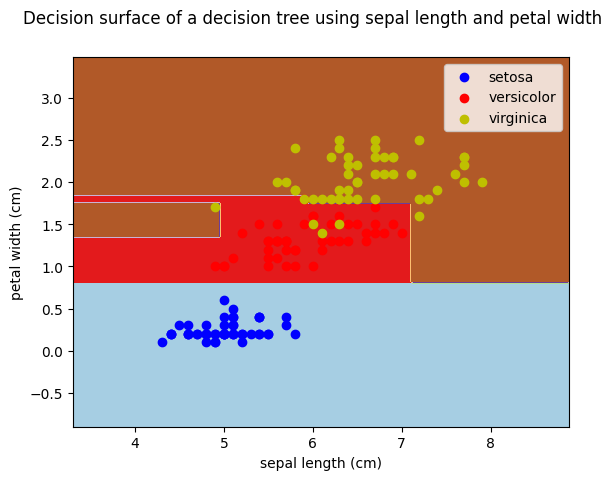

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Settings
n_classes = 3
plot_colors = "bry"  # blue-red-yellow
plot_step = 0.02

# Choose the sepal length and petal width attributes
pair = [0, 3]

# We only keep the two attributes
X = iris.data[:, pair]
y = iris.target

# Tree learning
clf = tree.DecisionTreeClassifier().fit(X, y)

# Display of the decision surface
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step), np.arange(y_min, y_max, plot_step))
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
cs = plt.contourf(xx, yy, Z, cmap=plt.cm.Paired)
plt.xlabel(iris.feature_names[pair[0]])
plt.ylabel(iris.feature_names[pair[1]])
plt.axis("tight")

# Display of learning points
for i, color in zip(range(n_classes), plot_colors):
    idx = np.where(y == i)
    plt.scatter(X[idx, 0], X[idx, 1], c=color, label=iris.target_names[i], cmap=plt.cm.Paired)
plt.axis("tight")
plt.suptitle("Decision surface of a decision tree using sepal length and petal width")
plt.legend()
plt.show()


**Sepal Width vs. Petal Length (indices 1 and 2):**

<ipython-input-23-39416142f967>:33: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X[idx, 0], X[idx, 1], c=color, label=iris.target_names[i], cmap=plt.cm.Paired)


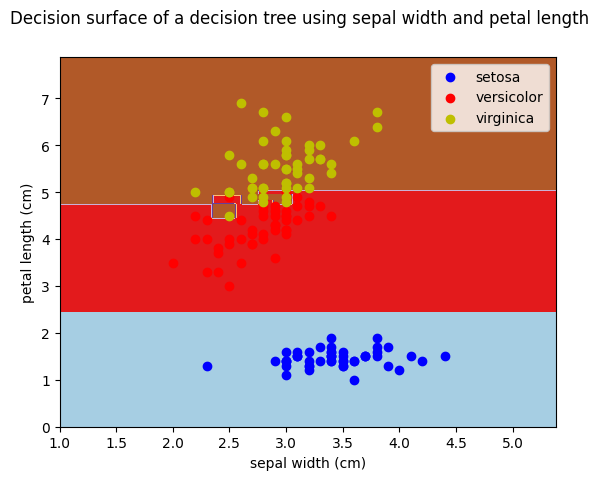

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Settings
n_classes = 3
plot_colors = "bry"  # blue-red-yellow
plot_step = 0.02

# Choose the sepal width and petal length attributes
pair = [1, 2]

# We only keep the two attributes
X = iris.data[:, pair]
y = iris.target

# Tree learning
clf = tree.DecisionTreeClassifier().fit(X, y)

# Display of the decision surface
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step), np.arange(y_min, y_max, plot_step))
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
cs = plt.contourf(xx, yy, Z, cmap=plt.cm.Paired)
plt.xlabel(iris.feature_names[pair[0]])
plt.ylabel(iris.feature_names[pair[1]])
plt.axis("tight")

# Display of learning points
for i, color in zip(range(n_classes), plot_colors):
    idx = np.where(y == i)
    plt.scatter(X[idx, 0], X[idx, 1], c=color, label=iris.target_names[i], cmap=plt.cm.Paired)
plt.axis("tight")
plt.suptitle("Decision surface of a decision tree using sepal width and petal length")
plt.legend()
plt.show()


**Sepal Width vs. Petal Width (indices 1 and 3):**

<ipython-input-24-ce4feed4f227>:33: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X[idx, 0], X[idx, 1], c=color, label=iris.target_names[i], cmap=plt.cm.Paired)


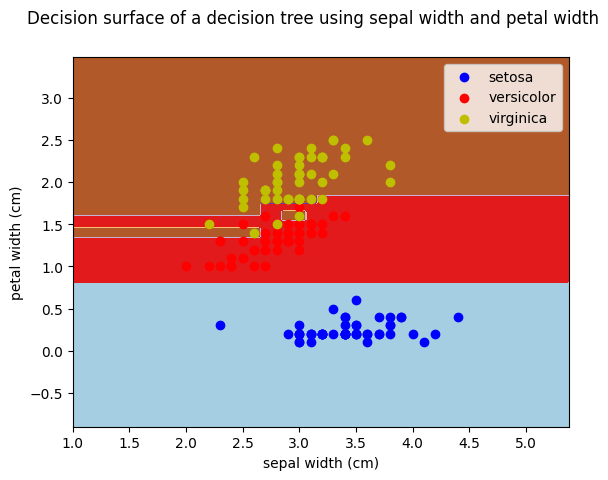

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Settings
n_classes = 3
plot_colors = "bry"  # blue-red-yellow
plot_step = 0.02

# Choose the sepal width and petal width attributes
pair = [1, 3]

# We only keep the two attributes
X = iris.data[:, pair]
y = iris.target

# Tree learning
clf = tree.DecisionTreeClassifier().fit(X, y)

# Display of the decision surface
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step), np.arange(y_min, y_max, plot_step))
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
cs = plt.contourf(xx, yy, Z, cmap=plt.cm.Paired)
plt.xlabel(iris.feature_names[pair[0]])
plt.ylabel(iris.feature_names[pair[1]])
plt.axis("tight")

# Display of learning points
for i, color in zip(range(n_classes), plot_colors):
    idx = np.where(y == i)
    plt.scatter(X[idx, 0], X[idx, 1], c=color, label=iris.target_names[i], cmap=plt.cm.Paired)
plt.axis("tight")
plt.suptitle("Decision surface of a decision tree using sepal width and petal width")
plt.legend()
plt.show()


## 	Decision trees for regression

For regression with decision trees, scikit-learn offers the `DecisionTreeRegressor` class. As for the classification, the  `fit(...)` takes as input the parameter `X` (attributes of the observations). Warning: the `y` are not class labels but real values.

In [ ]:
from sklearn import tree

X = [[0, 0], [2, 2]]
y = [0.5, 2.5]
clf = tree.DecisionTreeRegressor()
clf = clf.fit(X, y)
clf.predict([[1, 1]])

array([0.5])

In the following example, we will construct a sinusoidal signal affected by white noise and we will train a regression tree on this training data.

Text(0.5, 1.0, 'Noisy sine wave')

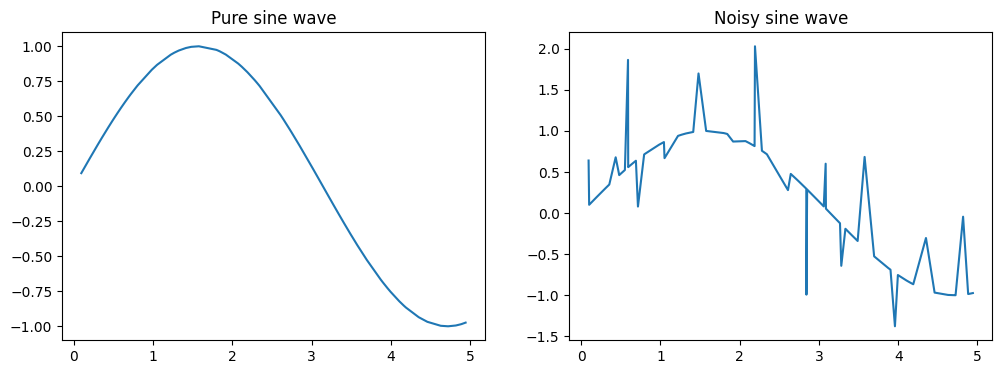

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeRegressor

# Create the training data
np.random.seed(0)
X = np.sort(5 * np.random.rand(80, 1), axis=0)
y = np.sin(X).ravel()

fig = plt.figure(figsize=(12, 4))
fig.add_subplot(121)
plt.plot(X, y)
plt.title("Pure sine wave")

# We add a random noise every 5 samples
y[::5] += 3 * (0.5 - np.random.rand(16))
fig.add_subplot(122)
plt.plot(X, y)
plt.title("Noisy sine wave")

The objective is to regress this signal `y` from the values of `x`. For this, we use a regression tree.

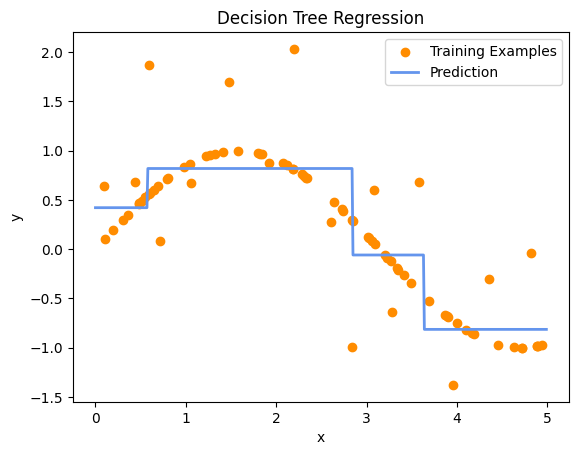

In [ ]:
# Learn the model
reg = DecisionTreeRegressor(max_depth=2)
reg.fit(X, y)

# Prediction on the same range of values
X_test = np.arange(0.0, 5.0, 0.01)[:, np.newaxis]
y_pred = reg.predict(X_test)

# Display of results
plt.figure()
plt.scatter(X, y, c="darkorange", label="Training Examples")
plt.plot(X_test, y_pred, color="cornflowerblue", label="Prediction", linewidth=2)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Decision Tree Regression")
plt.legend()
plt.show()

## Question 6:

Change the value of the `max_depth` parameter. What happens if we take too large a value? Too small? Change the rate of elements affected by noise (the `y[::5]`). When all elements are affected by noise, should a high or low value for `max_depth` be preferred?

** function to add noise to the dataset.**

In [ ]:
from sklearn import tree
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import numpy as np
import matplotlib.pyplot as plt

# Load the Iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# Function to add noise to the labels
def add_noise(y, noise_rate=0.2):
    np.random.seed(42)
    noisy_y = y.copy()
    n_samples = len(y)
    n_noisy = int(noise_rate * n_samples)
    noisy_indices = np.random.choice(n_samples, n_noisy, replace=False)
    noisy_labels = np.random.choice(np.unique(y), n_noisy)
    noisy_y[noisy_indices] = noisy_labels
    return noisy_y


** Experiment with max_depth Values**

In [ ]:
# Function to evaluate decision tree with different max_depth
def evaluate_max_depth(max_depth, X, y):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
    clf = tree.DecisionTreeClassifier(max_depth=max_depth)
    clf.fit(X_train, y_train)
    train_score = clf.score(X_train, y_train)
    test_score = clf.score(X_test, y_test)
    print(f"max_depth = {max_depth} | Training Score: {train_score:.4f} | Testing Score: {test_score:.4f}")
    return clf

# Evaluate for different max_depth values
for depth in [None, 5, 3, 1]:
    print(f"Evaluating max_depth = {depth}:")
    evaluate_max_depth(depth, X, y)
    print()


Evaluating max_depth = None:
max_depth = None | Training Score: 1.0000 | Testing Score: 1.0000

Evaluating max_depth = 5:
max_depth = 5 | Training Score: 1.0000 | Testing Score: 1.0000

Evaluating max_depth = 3:
max_depth = 3 | Training Score: 0.9619 | Testing Score: 1.0000

Evaluating max_depth = 1:
max_depth = 1 | Training Score: 0.6476 | Testing Score: 0.7111



 **Introduce Noise and Analyze max_depth Impact**

In [ ]:
# Introduce noise to the dataset
noisy_y = add_noise(y, noise_rate=0.2)  # 20% noise

# Evaluate the effect of noise with different max_depth values
print("Evaluating with Noise Added (20%):")
for depth in [None, 5, 3, 1]:
    print(f"Evaluating max_depth = {depth} with noise:")
    evaluate_max_depth(depth, X, noisy_y)
    print()


Evaluating with Noise Added (20%):
Evaluating max_depth = None with noise:
max_depth = None | Training Score: 1.0000 | Testing Score: 0.4889

Evaluating max_depth = 5 with noise:
max_depth = 5 | Training Score: 0.9905 | Testing Score: 0.4889

Evaluating max_depth = 3 with noise:
max_depth = 3 | Training Score: 0.9524 | Testing Score: 0.4889

Evaluating max_depth = 1 with noise:
max_depth = 1 | Training Score: 0.6476 | Testing Score: 0.4889



** Analyze the Impact of Noise on All Elements**

In [ ]:
# Introduce noise to all elements
noisy_y_full = add_noise(y, noise_rate=1.0)  # 100% noise

# Evaluate for different max_depth values with full noise
print("Evaluating with Full Noise (100%):")
for depth in [None, 5, 3, 1]:
    print(f"Evaluating max_depth = {depth} with full noise:")
    evaluate_max_depth(depth, X, noisy_y_full)
    print()


Evaluating with Full Noise (100%):
Evaluating max_depth = None with full noise:
max_depth = None | Training Score: 1.0000 | Testing Score: 0.3556

Evaluating max_depth = 5 with full noise:
max_depth = 5 | Training Score: 0.6286 | Testing Score: 0.3111

Evaluating max_depth = 3 with full noise:
max_depth = 3 | Training Score: 0.5143 | Testing Score: 0.4000

Evaluating max_depth = 1 with full noise:
max_depth = 1 | Training Score: 0.4190 | Testing Score: 0.3778



## Question 7:

To deepen, load the Diabetes dataset from the `sklearn.datasets` module and make a random partition into learning part and test part (70% learning, 30% testing). Build a regression tree model on this basis. Calculate the root mean square error on the test set. Do a grid search to find the `max_depth` parameter value that minimizes this error.

Step 1: Import Libraries and Load the Dataset

In [ ]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

# Load the Diabetes dataset
diabetes = load_diabetes()
X, y = diabetes.data, diabetes.target

# Split the dataset into 70% training and 30% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


Step 2: Build and Train a Decision Tree Regressor

In [ ]:
# Initialize a Decision Tree Regressor
regressor = DecisionTreeRegressor()

# Train the model on the training set
regressor.fit(X_train, y_train)

# Predict on the test set
y_pred = regressor.predict(X_test)

# Calculate the Root Mean Square Error (RMSE)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE (without tuning max_depth): {rmse:.4f}")


RMSE (without tuning max_depth): 75.4269


Step 3: Perform Grid Search to Optimize max_depth

In [ ]:
# Define a parameter grid for max_depth
param_grid = {'max_depth': np.arange(1, 21)}  # Try max_depth from 1 to 20

# Initialize the GridSearchCV with DecisionTreeRegressor
grid_search = GridSearchCV(DecisionTreeRegressor(), param_grid, scoring='neg_mean_squared_error', cv=5)

# Fit the grid search model on the training data
grid_search.fit(X_train, y_train)

# Get the best parameters from the grid search
best_max_depth = grid_search.best_params_['max_depth']
print(f"Best max_depth: {best_max_depth}")

# Train the regressor with the best max_depth
best_regressor = DecisionTreeRegressor(max_depth=best_max_depth)
best_regressor.fit(X_train, y_train)

# Predict on the test set with the best model
y_pred_best = best_regressor.predict(X_test)

# Calculate the RMSE with the optimized model
rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))
print(f"RMSE (with tuned max_depth): {rmse_best:.4f}")


Best max_depth: 3
RMSE (with tuned max_depth): 60.1396
